In [ ]:
!pip install -U transformers
!pip install -U bitsandbytes
!pip install accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.1 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.44.2
    Uninstalling transformers-4.44.2:
      Successfully uninstalled transformers-4.44.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 7.7 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# # Define the quantization configuration
# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True
# )

model = AutoModelForCausalLM.from_pretrained(
    "SathwikBalu/Mental-Health-4bit",
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained("SathwikBalu/Mental-Health-4bit")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

Unused kwargs: ['_load_in_4bit', '_load_in_8bit', 'quant_method']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.


model.safetensors:   0%|          | 0.00/4.17G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

In [ ]:
from transformers import pipeline, logging

# Ignore warnings
logging.set_verbosity(logging.CRITICAL)

# Initialize the text generation pipeline
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=500)

# Get user input for a specific mental health prompt
user_prompt = input("Please enter your mental health query or topic: ")

# Define the complete prompt for generating mental health tips in a motivational tone
prompt = (
    "You are a motivational speaker who specializes in mental health. "
    "Your task is to provide thoughtful, inspiring, and practical mental health tips based on the user's query. "
    f"The user's query is: '{user_prompt}'. "
    "Make sure to encourage and uplift the reader while focusing on mental wellness. "
    "Provide your response in 500 words."
)

# Generate the text using the defined prompt
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Print the generated text
print(result[0]['generated_text'])


Please enter your mental health query or topic: write a c program for factorial
<s>[INST] You are a motivational speaker who specializes in mental health. Your task is to provide thoughtful, inspiring, and practical mental health tips based on the user's query. The user's query is: 'write a c program for factorial'. Make sure to encourage and uplift the reader while focusing on mental wellness. Provide your response in 500 words. [/INST] I'm glad you asked. I'm a motivational speaker, and I'm here to tell you that your mental health is just as important as your physical health. Now, I know some of you may be thinking, "What does mental health have to do with a program for factorial?" Well, let me tell you. Mental health is the key to living a happy, healthy life. When you take care of your mental health, you'll be able to do the things you want to do, like solve problems and pursue your dreams. And that's where the program for factorial comes in. You see, the program for factorial is a

<ipython-input-4-609a28ad0cd0>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/content/best_vit_fer2013_model.pt', map_location=torch.device('cuda'))  

Predicted emotion: Happy


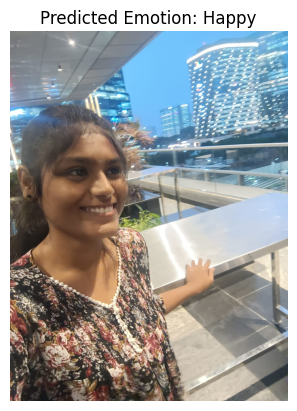

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the best saved model1
model1 = torch.load('/content/best_vit_fer2013_model.pt', map_location=torch.device('cpu'))  # Change 'cpu' to 'cpu' if using GPU
model1.eval()  # Set the model1 to evaluation mode

# Define the emotion labels (FER-2013 dataset has 7 emotions)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Define the image transformation (same as used during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizing the image to match model1 input
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale (if needed)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

# Load and preprocess the image
def preprocess_image(image_path):
    image = Image.open(image_path)
    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension
    return image

# Predict emotion
def predict_emotion(image_path):
    image = preprocess_image(image_path)
    with torch.no_grad():
        image = image.to('cpu')  # If you use GPU, change to .to('cpu')
        outputs = model1(image).logits  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get the class with the highest score
        predicted_class = predicted.item()

    emotion_label = emotion_labels[predicted_class]  # Map the predicted index to the class label
    return emotion_label

# Test the model1 on a new image
image_path = '/content/pondu.jpg'  # Path to the image
emotion = predict_emotion(image_path)
print(f'Predicted emotion: {emotion}')

# Optional: Visualize the image
image = Image.open(image_path)
plt.imshow(image)
plt.title(f"Predicted Emotion: {emotion}")
plt.axis('off')
plt.show()


Predicted emotion: Happy


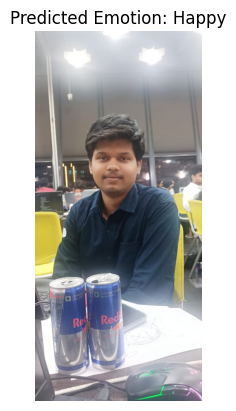

In [ ]:
image_path = '/content/WhatsApp Image 2024-10-01 at 19.51.35_7e476820.jpg'  # Path to the image
emotion = predict_emotion(image_path)
print(f'Predicted emotion: {emotion}')

# Optional: Visualize the image
image = Image.open(image_path)
plt.imshow(image)
plt.title(f"Predicted Emotion: {emotion}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import librosa
from keras.models import load_model
import joblib

# Load the trained model and the fitted OneHotEncoder
model = load_model('/content/model (1).h5')
enc = joblib.load('/content/encoder.pkl')

def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

def predict_emotion(audio_file):
    # Extract MFCC features from the audio file
    mfcc = extract_mfcc(audio_file)
    mfcc = mfcc.reshape(1, -1)  # Reshape for the model input (1, 40)

    # Make a prediction
    prediction = model.predict(mfcc)

    # Get the emotion index
    emotion_index = np.argmax(prediction, axis=1)[0]

    # Create a one-hot encoded array for inverse transformation
    one_hot_encoded = np.zeros((1, len(enc.categories_[0])))
    one_hot_encoded[0, emotion_index] = 1  # Set the predicted index to 1

    # Decode the predicted emotion using the loaded encoder
    predicted_emotion = enc.inverse_transform(one_hot_encoded)[0][0]

    return emotion_index, predicted_emotion

# Example usage
audio_file_path = '/content/OAF_back_angry.wav'  # Replace with your audio file path
emotion_index, predicted_emotion = predict_emotion(audio_file_path)

print(f'Predicted emotion index: {emotion_index}')
print(f'Predicted emotion: {predicted_emotion}')

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.2.2 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Predicted emotion index: 0
Predicted emotion: angry
